![NVIDIA Logo](images/nvidia.png)

# A Most Simple Pipeline

In this notebook you will begin to familiarize yourself with building Morpheus pipelines using the Python SDK by building and running perhaps the most simple pipeline possible.

In doing so you'll begin to get familiar with several of the required steps we will be using throughout the workshop even when we start to build much more complicated pipelines.

---

## Objectives

By the time you complete this notebook you will be able to:

- Build and run a very simple Morpheus pipeline using the Python SDK.
- Visualize pipeline structures.
- Enable and view logging for running pipelines.

---

## Imports

The following imports are used in this notebook. We will look at each of them individually as they are used in code.

In [2]:
import logging

import cudf
from IPython.display import Image

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline
from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.utils.logger import configure_logging, reset_logging

---

## Morpheus Pipelines

As a reminder from the workshop introduction, Morpheus pipelines consist of stages, with a **source** stage being required as the starting point of each pipeline.

![morpheus-at-a-glance](images/morpheus-at-a-glance.png)

To being, we are going to create the most basic pipeline possible which consists of only a source stage.

---

## Create a Config Object

Every pipeline requires an instance of `morpheus.config.Config`. `Config()` instantiates a global configuration object which will be passed to each stage in the pipeline.

When creating a configuration object, there are many settings we can configure:

 - `config.execution_mode` sets the execution  mode to GPU or CPU mode, this course will emphasize the GPU execution mode.
 - `config.mode` sets type of pipeline to configure.
    - `FIL` for Forest Inference Library/XGBoost.
    - `NLP` Natural Language Processing.
    - `AE` Autoencoder.
    - `OTHER` for custom pipelines. 
 - `config.num_threads` sets the number of threads to use in the pipeline, higher values increase concurrency.
 - `config.pipeline_batch_size` sets the batch size of the pipeline, higher values can help saturate the GPU at the expense of memory and latency.
 - `config.model_max_batch_size` defines maximum batch size for model, e.g. `max_batch_size` parameter in the `abp-pcap-xgb` Triton Inference Server `config.pbtxt` file.
 - `config.feature_length` defines feature length expected by the model, e.g. size of `dims` in `input` name `input__0` in the `abp-pcap-xgb` Triton Inference Server `config.pbtxt`.
 - `config.class_labels` defines the column name in our output file that will hold inference results.
 - `config.edge_buffer_size` defines the size of buffers between stages, higher values increase throughput at expense of memory and latency while lower values decrease latency at the expense of throughput.

For now we will instantiate a pipeline config without any arguments.

In [3]:
config = Config()
config

Config(execution_mode=<ExecutionMode.GPU: 'GPU'>, debug=False, log_level=30, log_config_file=None, plugins=None, mode=<PipelineModes.OTHER: 'OTHER'>, _pipeline_batch_size=256, _model_max_batch_size=8, feature_length=256, num_threads=1, edge_buffer_size=128, class_labels=[], ae=None, fil=None, frozen=False)

---

## Create a Linear Pipeline

Once we have a config instance we can create a pipeline. Here we create a linear pipeline using `morpheus.pipeline.LinearPipeline` and passing it our `config` instance.

In [4]:
pipeline = LinearPipeline(config)

As the name suggests, `LinearPipeline` creates a pipeline whose stages will be executed linearly. Later in the workshop we will look in depth at the creation of more flexible non-linear pipelines.

---

## Synthetic User Authentication Logs

In the next several notebooks we'll be working with a small synthetically-generated JSON lines file of simple user authentication logs, which we load into a dataframe here so you can view its contents.

In [5]:
input_file = 'data/simple_user_log.jsonlines'

In [6]:
cudf.read_json(input_file, lines=True)

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


---

## Create Pipeline Source Stage

We claimed above that every pipeline is required to begin with a source stage. We have many options when it comes to the source of the data for our pipelines, and Morpheus ships with several pre-built source stages for sourcing from file, local memory, HTTP servers, Kafka, and more. We can also, as you'll learn how to do later, create custom stages for arbitrary forms of data ingestion.

Here we will use `FileSourceStage`, which like all stages for a given pipeline requires we pass it our pipeline's `config` object.

`FileSourceStage` also provides an `iterative` parameter, by default set to `False`. If we wished, we could set `iterative=True` to enable iterative mode. Iterative mode will emit dataframes one at a time, otherwise a list of dataframes is emitted. Iterative mode is good for interleaving source stages when needed.

In [7]:
print(FileSourceStage.__doc__)


    Load messages from a file.

    Source stage is used to load messages from a file and dumping the contents into the pipeline immediately. Useful for
    testing performance and accuracy of a pipeline.

    Parameters
    ----------
    c : `morpheus.config.Config`
        Pipeline configuration instance.
    filename : pathlib.Path, exists = True, dir_okay = False
        Name of the file from which the messages will be read.
    iterative : boolean, default = False, is_flag = True
        Iterative mode will emit dataframes one at a time. Otherwise a list of dataframes is emitted. Iterative mode is
        good for interleaving source stages.
    file_type : `morpheus.common.FileTypes`, optional, case_sensitive = False
        Indicates what type of file to read. Specifying 'auto' will determine the file type from the extension.
        Supported extensions: 'csv', 'json', 'jsonlines' and 'parquet'.
    repeat : int, default = 1, min = 1
        Repeats the input dataset multiple

In [8]:
pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

<from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>

---

## Build the Pipeline

Before we can run a pipeline it needs to be built, which we can do with its `build` method.

Often we will get errors when first trying to build a pipeline if we've constructed a pipeline that is malformed in some way. If you like, you can think about pipeline building like compiling source code, where the compiler might provide you with errors in your code even before you've tried to execute it.

In [9]:
pipeline.build()

It's worth mentioning that if you were to execute the cell immediately above again you would receive an error indicating that a pipeline can only be built once.

This is likely to happen to you at some point in the workshop. When it does, you will need to create a new config instance, and re-run any code after the creation of your config, which most likely will be the creation of the pipeline itself.

If you'd like, run the cell immediately above again to see the error, and then go back and re-run the cells starting with your config instance creation. As a tip, you can use SHIFT+Enter repeatedly to quickly execute Jupyter cells and continue on to the next.

---

## Pipeline Visualization

Once a pipeline is successfully built, we can use its `visualize` method to generate a PNG image of the pipeline which we do here, and then then load for viewing.

In [10]:
viz_file = './pipeline_visualizations/most_simple.png'
pipeline.visualize(viz_file)

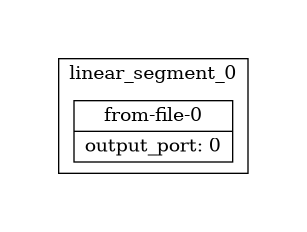

In [11]:
Image(filename=viz_file)

At this point in time the visualization is quite plain, but as our pipelines get more complex, we'll continue to visualize them to help us understand them more clearly.

---

## Enable Logging

Often we might wish to enable logging for our pipeline, which we do here using `morpheus.utils.logger.configure_logging`.

We've coupled `reset_logging` together with `configure_logging` in the cell below for convenience in this classroom setting, so that when/if you wish to rebuild or re-run the pipeline, you can get a fresh logger each time.

In [12]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


---

## Run the Pipeline

Now all we have to do is run the pipline by invoking either its `run` or `run_async` method.

Within this Jupyter environment, which is running an asyncio loop as part of its own execution, we are required to run `run_async`.

In [13]:
await pipeline.run_async()

Although we don't see any output here from running the pipeline, if you look slightly above, where we configured the logger, you'll see some logging from the pipeline run.

Again, not much is happening at this point in time, but the logs certainly indicate that the pipeline started and ran to completion.